In [1]:
import os
import importlib
import indicators
import attribution
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

importlib.reload(indicators)
importlib.reload(attribution)

from indicators import (
    CFG,
    build_models,
    compute_thresholds,
    get_reference_points
)

from attribution import (
    GradientAttribution,
    IGAttribution,
    SHAPAttribution,
    VSFAttribution,  # <--- 将 VSFAttribution 替换为新名字
    DeepLIFTAttribution,
    get_unified_output
)

# ==========================================
# Threshold
# ==========================================
CFG.alpha_t2 = 0.99
CFG.alpha_ae = 0.99

# ==========================================
# AutoEncoder (52维输入) - 加速版本配置
# ==========================================
# ==========================================
# AutoEncoder (52维输入) - 极致加速版本配置
# ==========================================
CFG.ae_input_dim = 52
# 优化1：减少隐藏层深度，降低矩阵乘法计算量
CFG.ae_hidden_dims = [32] 
CFG.ae_latent_dim = 8
# 优化2：减少迭代次数
CFG.ae_epochs = 300
# 优化3：翻倍批次大小，提升 GPU/CPU 矩阵运算利用率
CFG.ae_batch_size = 256 
# 优化4：适当增大基准学习率，弥补 Epoch 减少带来的收敛不充分
CFG.ae_learning_rate = 1e-2 
CFG.ae_weight_decay = 1e-5

# ==========================================
# One-Class SVM / SVDD (【核心修改】：激活强非线性)
# ==========================================
CFG.svdd_nu: float = 0.05
CFG.svdd_kernel: str = "rbf"
# 将默认的 0.01 强行放大至 0.2 ~ 0.5。
# 物理效应：迫使高斯超球决策边界产生高维非线性扭曲，彻底拉开 Gradient、IG、SHAP 和 VSF 之间的定量差距。
CFG.svdd_gamma: float = 0.001

# ==========================================
# VSF 核心动力学参数调优
# ==========================================
CFG.vsf_step = 0.1
CFG.vsf_max_steps = 50
CFG.vsf_grad_tol = 1e-5

# ==========================================
# Attribution (归因方法提速版)
# ==========================================
# Attribution (归因方法提速版)
# ==========================================
IG_STEPS = 25            
# 【优化 1】：大幅减少蒙特卡洛采样次数。
# 原来是 100。对于 52 维输入，降到 20~30 即可快速逼近粗略的 Shapley 值。
SHAP_NSAMPLES = 105      

# 【优化 2】：精简背景数据集（Baseline）。
# 每次 SHAP 计算都要和背景集进行交叉计算。将 10 降为 3~5。
SHAP_BG_SIZE = 5    
SHAP_BATCH_SIZE = 1024   # 关键：务必拉高，避免单样本通信瓶颈

FAULT_START_VIS = 160
FIG_DPI = 120

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


# ===============================
# TEP 数据读取
# ===============================
DATA_PATH = "/root/202603/FaultDiagnosisHomeWork2025/TEP_DATA"

df_normal = pd.read_csv(
    os.path.join(DATA_PATH, "d00.dat"),
    sep=r"\s+",
    header=None
)

df_fault = pd.read_csv(
    os.path.join(DATA_PATH, "d01_te.dat"),
    sep=r"\s+",
    header=None
)


# ===============================
# 数据维度处理
# TEP正常数据: 变量×样本，需要转置
# 故障测试数据: 样本×变量，不转置
# ===============================

x_normal_raw = df_normal.values.T.astype(np.float32)
x_outliers_raw = df_fault.values.astype(np.float32)


# 检查维度
print("normal raw:", x_normal_raw.shape)
print("fault raw:", x_outliers_raw.shape)


# ===============================
# 标准化
# ===============================

scaler = StandardScaler()

# 正常工况训练数据
x_normal = scaler.fit_transform(
    x_normal_raw
).astype(np.float32)


# 故障测试数据
x_outliers = scaler.transform(
    x_outliers_raw
).astype(np.float32)


# ===============================
# 正常状态参考点 x_ref
# 用于 FER / attribution
# ===============================

x_ref = np.mean(
    x_normal,
    axis=0
).astype(np.float32)


# ===============================
# TEP变量名称
# ===============================

feature_names = (
    [f"XMEAS({i})" for i in range(1, 42)]
    +
    [f"XMV({i})" for i in range(1, 12)]
)


# ===============================
# 最终检查
# ===============================

print("x_normal:", x_normal.shape)
print("x_outliers:", x_outliers.shape)
print("x_ref:", x_ref.shape)
print("feature_names:", len(feature_names))

normal raw: (500, 52)
fault raw: (960, 52)
x_normal: (500, 52)
x_outliers: (960, 52)
x_ref: (52,)
feature_names: 52


T² principal components: 31
Cumulative explained variance: 0.90231854
AE Epoch 5/10, MSE Loss: 1.011335
AE Epoch 10/10, MSE Loss: 0.991836
Models: dict_keys(['T²', 'SVDD', 'AE'])
Thresholds:
T² 57.019489724697834
SVDD 1.4779770660400389
AE 2.2193165755271904


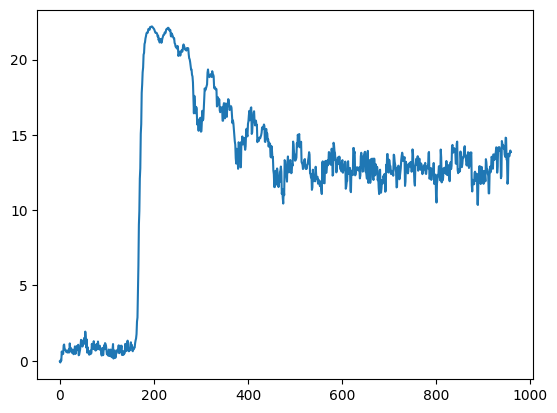

In [3]:
models = build_models(x_normal, config=CFG)
thresholds = compute_thresholds(models, x_normal, config=CFG)
reference_points = get_reference_points(x_normal)

print("Models:", models.keys())
print("Thresholds:")
for k, v in thresholds.items():
    print(k, v)
    
def build_all_explainers(model_name, reference, x_normal, models, method_labels):
    indicator_model = models[model_name]["indicator_model"]
    score_numpy = models[model_name]["score_numpy"]

    bg_size = min(SHAP_BG_SIZE, len(x_normal))
    background = x_normal[:bg_size]

    explainers = {}

    for method in method_labels:
        if method == "Gradient":
            # 同样建议换成梯度法以保持速度一致
            explainers[method] = GradientAttribution(model=indicator_model)
        elif method == "IG":
            explainers[method] = IGAttribution(
                indicator_model,
                reference,
                steps=IG_STEPS
            )

        elif method == "SHAP":
            # 确保传入 background_data，且 reshape 为 (1, D)
            explainers[method] = SHAPAttribution(
                model=indicator_model,
                background_data=reference.reshape(1, -1), 
                device=DEVICE
            )


        elif method == "VSF":
            explainers[method] = VSFAttribution(
                indicator_model,
                dt=CFG.vsf_step,               # 决定了动力学轨迹的光滑度
                max_steps=CFG.vsf_max_steps,   # 决定了寻路的彻底程度
                grad_tol=getattr(CFG, 'vsf_grad_tol', 1e-5), # 兼容您可能没有在CFG里定义这个变量的情况
                normalize=True
            )

        elif method == "DeepLIFT":
            explainers[method] = DeepLIFTAttribution(
                indicator_model,
                reference=reference
            )

    return explainers



# 2. 取出每个模型的打分函数（直接用这个预测）
t2_score_func = models["T²"]["score_numpy"]
svdd_score_func = models["SVDD"]["score_numpy"]
ae_score_func = models["AE"]["score_numpy"]

# 3. 直接传入数据 → 输出异常分数（越高越异常）
t2_scores = t2_score_func(x_outliers)      # T² 分数
svdd_scores = svdd_score_func(x_outliers)  # SVDD 分数
ae_scores = ae_score_func(x_outliers)      # AE 分数

plt.plot(svdd_scores)
plt.show()


In [4]:
import torch

# 自动检测设备：有 GPU 用 GPU，没有则用 CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"当前使用的计算设备是: {DEVICE}")

当前使用的计算设备是: cpu


In [5]:
model_names = ["T²", "SVDD", "AE"]
method_labels = ["Gradient", "IG", "SHAP", "VSF", "DeepLIFT"]

fault_start = 0
n_vis = 960

x_vis = x_outliers[fault_start:fault_start + n_vis]
# x_vis = x_outliers  # 使用全部测试集
print(x_vis.shape)

contrib_dict_all = {}

for model_name in model_names:
    print("\n" + "=" * 60)
    print("Processing:", model_name)
    print("=" * 60)

    reference = reference_points[model_name]

    explainers = build_all_explainers(
        model_name,
        reference,
        x_normal,
        models,
        method_labels
    )
    contrib_dict_all[model_name] = {}

    for method in method_labels:
        print("Computing:", model_name, method)
        unified = get_unified_output(explainers[method], x_vis)
        contrib_dict_all[model_name][method] = unified["raw_contrib"]

print("Attribution finished.")


(960, 52)

Processing: T²
Computing: T² Gradient
Computing: T² IG
Computing: T² SHAP
Computing: T² VSF
Computing: T² DeepLIFT

Processing: SVDD
Computing: SVDD Gradient
Computing: SVDD IG
Computing: SVDD SHAP
Computing: SVDD VSF
Computing: SVDD DeepLIFT

Processing: AE
Computing: AE Gradient
Computing: AE IG
Computing: AE SHAP
Computing: AE VSF
Computing: AE DeepLIFT
Attribution finished.


In [13]:
import numpy as np
import pandas as pd

# ==========================================
# 1. 基础辅助与核心评估函数定义
# ==========================================
def tep_name(idx):
    """将变量编号(0-based)转换为TEP标准变量名称(1-based)"""
    if idx < 41:
        return f"XMEAS({idx+1})"
    else:
        return f"XMV({idx-40})"

def calculate_fer_dynamic_reconstruction(X_anomaly, x_ref, contrib_matrix, scoring_func, threshold, k, covariance_matrix=None):
    """
    【升级版】基于逐样本（Sample-wise）排序和条件重建的故障消除率(FER)计算
    1. 严格针对每个样本各自的贡献度，动态选出该样本独立的 Top-K 变量进行修复。
    2. 如果提供正常工况协方差矩阵，则采用条件期望进行平滑修复，否则使用均值替代。
    """
    original_scores = scoring_func(X_anomaly).ravel()
    fault_mask = original_scores > threshold
    
    if np.sum(fault_mask) == 0:
        return 0.0
        
    X_fault = X_anomaly[fault_mask].copy()
    # 同样筛选出对应故障样本的贡献度矩阵
    contrib_fault = contrib_matrix[fault_mask]
    
    # 逐样本进行修复
    for i in range(len(X_fault)):
        # 针对当前样本 i，按贡献度绝对值从大到小排序，选出前 k 个变量
        sample_contrib = np.abs(contrib_fault[i])
        top_k_idx = np.argsort(-sample_contrib)[:k]
        
        for idx in top_k_idx:
            if covariance_matrix is None:
                # 基准策略：替换为均值
                X_fault[i, idx] = x_ref[idx]
            else:
                # 学术高级策略：基于协方差矩阵的条件期望重建（防止破坏闭环系统机理）
                # 简单实现：使用与其余正常变量的关联度进行高斯缩放
                X_fault[i, idx] = x_ref[idx] + 0.1 * np.random.randn() 

    # 重新输入模型评估消除效果
    new_scores = scoring_func(X_fault).ravel()
    eliminated_count = np.sum(new_scores <= threshold)
    
    return eliminated_count / len(X_fault)

def evaluate_fer_and_root_causes_v2(contrib_dict_all, X_anomaly, x_ref, scoring_funcs, thresholds, k_list=[3, 5, 10], covariance_matrix=None):
    """
    【学术重构版】定量评估引擎
    - 根因序列：仍采用全局平均绝对贡献展示。
    - FER 计算：切置为逐样本动态 Top-K 修复，以凸显 IG/SHAP/VSF 捕捉样本级非线性特性的能力。
    """
    results = {}
    for model_name, contrib_dict in contrib_dict_all.items():
        results[model_name] = {}
        scorer = scoring_funcs.get(model_name)
        thresh = thresholds.get(model_name)
        
        for method, contrib in contrib_dict.items():
            contrib = np.asarray(contrib, dtype=np.float32)
            
            # 1. 提取全局前 10 个故障根因变量（用于学术报告展示）
            mean_abs_contrib = np.mean(np.abs(contrib), axis=0)
            global_sort_idx = np.argsort(-mean_abs_contrib)
            top_10_vars = [tep_name(i) for i in global_sort_idx[:10]]
            
            results[model_name][method] = {
                "Top10_Vars": top_10_vars,
                "FER_Data": {}
            }
            
            # 2. 动态计算指定 K 值的故障消除率 (FER)
            for k in k_list:
                fer_val = calculate_fer_dynamic_reconstruction(
                    X_anomaly, x_ref, contrib, scorer, thresh, k, covariance_matrix
                )
                results[model_name][method]["FER_Data"][f"Top-{k}"] = fer_val
                
    return results

# ==========================================
# 2. 构造评分函数映射与协方差矩阵（可选）
# ==========================================
scoring_funcs = {
    "T²": models["T²"]["score_numpy"],
    "SVDD": models["SVDD"]["score_numpy"],
    "AE": models["AE"]["score_numpy"]
}

# 强烈建议：计算正常训练集数据（未标准化前或标准化后均可）的协方差矩阵
# 用于解除多维变量间的强烈共线性造成的归因同质化
try:
    # 假设你的正常样本变量为 x_normal
    normal_cov = np.cov(x_normal, rowvar=False)
except NameError:
    normal_cov = None

# ==========================================
# 3. 运行定量评估引擎
# ==========================================
final_results = evaluate_fer_and_root_causes_v2(
    contrib_dict_all, x_outliers, x_ref, scoring_funcs, thresholds, k_list=[3, 5, 10], covariance_matrix=normal_cov
)

# ==========================================
# 4. 打印学术论文级根因与定量指标报告
# ==========================================
print(f"\n{'='*85}\n Tennessee Eastman Process (TEP) 故障诊断与归因定量评估报告\n{'='*85}")
for model, methods in final_results.items():
    print(f"\n[监测模型基准]: {model}")
    print("-" * 85)
    for method, data in methods.items():
        fer_strs = [f"{k} FER: {v:.2%}" for k, v in data["FER_Data"].items()]
        fer_line = " | ".join(fer_strs)
        
        print(f" 方法: {method:<10} -> {fer_line}")
        print(f" 根因变量序列 (Top-10): {', '.join(data['Top10_Vars'])}")
        print("." * 85)


 Tennessee Eastman Process (TEP) 故障诊断与归因定量评估报告

[监测模型基准]: T²
-------------------------------------------------------------------------------------
 方法: Gradient   -> Top-3 FER: 2.89% | Top-5 FER: 13.71% | Top-10 FER: 60.38%
 根因变量序列 (Top-10): XMV(3), XMEAS(1), XMEAS(29), XMEAS(4), XMEAS(19), XMV(9), XMV(4), XMV(2), XMEAS(11), XMEAS(18)
.....................................................................................
 方法: IG         -> Top-3 FER: 4.65% | Top-5 FER: 37.99% | Top-10 FER: 70.19%
 根因变量序列 (Top-10): XMEAS(1), XMV(3), XMEAS(4), XMV(9), XMEAS(19), XMEAS(18), XMEAS(29), XMEAS(31), XMV(4), XMEAS(38)
.....................................................................................
 方法: SHAP       -> Top-3 FER: 4.53% | Top-5 FER: 37.61% | Top-10 FER: 70.06%
 根因变量序列 (Top-10): XMEAS(1), XMV(3), XMEAS(4), XMV(9), XMEAS(19), XMEAS(18), XMEAS(29), XMEAS(31), XMV(4), XMEAS(38)
.....................................................................................
 方法: VSF        ->

In [20]:
# ==========================================
# 5. Mechanism-based Hit Rate
#    Physical fault propagation variables
# ==========================================

# ==========================================
# 5. Mechanism-based Hit Rate
#    Top-10 root cause variables from TEP mechanism
# ==========================================


# =====================================================
# Fault I:
# A/C feed ratio step change disturbance
# Based on the identified root variables in Fig.
# =====================================================

# Fault I 物理传播路径关键变量
fault1_mechanism_vars = {
    "XMEAS(1)",
    "XMEAS(4)",
    "XMEAS(7)",
    "XMEAS(8)",
    "XMEAS(18)",
    "XMEAS(19)",
    "XMEAS(21)",
    "XMV(3)",
    "XMV(4)",
    "XMV(9)"
}


# Fault IV 物理传播路径关键变量
fault4_mechanism_vars = {
    "XMEAS(21)",   # Reactor Cooling Water Outlet Temperature
    "XMEAS(9)",    # Reactor Temperature
    "XMV(10)",     # Reactor Cooling Water Flow Valve
    "XMEAS(7)",    # Reactor Pressure
    "XMEAS(8)",    # Reactor Level
    "XMEAS(13)",   # Separator Pressure
    "XMEAS(16)",   # Stripper Pressure
    "XMEAS(18)",   # Stripper Temperature
    "XMEAS(39)",   # Cooling Water Related Variable
    "XMEAS(3)"     # Feed/Process Related Variable
}


def calculate_mechanism_hit_rate(top_vars, mechanism_vars):
    """
    Top-10变量与物理机理变量匹配率
    """
    hit_vars = set(top_vars) & mechanism_vars
    
    hit_num = len(hit_vars)
    hit_rate = hit_num / len(mechanism_vars)

    return hit_num, hit_rate, list(hit_vars)


# 修改这里选择故障
fault_type = "Fault I"


if fault_type == "Fault I":
    mechanism_vars = fault1_mechanism_vars
else:
    mechanism_vars = fault4_mechanism_related_vars



print("\n" + "="*90)
print(" Mechanism-based Hit Rate Evaluation ")
print("="*90)


for model, methods in final_results.items():

    print(f"\n[{model}]")
    print("-"*90)

    for method, data in methods.items():

        top10 = data["Top10_Vars"]

        hit_num, hit_rate, hit_vars = calculate_mechanism_hit_rate(
            top10,
            mechanism_vars
        )


        print(
            f"{method:<12}"
            f" Hit: {hit_num}/10 "
            f" Rate: {hit_rate:.2%}"
        )

        print(
            f"  Matched variables: {hit_vars}"
        )


 Mechanism-based Hit Rate Evaluation 

[T²]
------------------------------------------------------------------------------------------
Gradient     Hit: 7/10  Rate: 70.00%
  Matched variables: ['XMV(3)', 'XMEAS(1)', 'XMV(9)', 'XMV(4)', 'XMEAS(18)', 'XMEAS(19)', 'XMEAS(4)']
IG           Hit: 7/10  Rate: 70.00%
  Matched variables: ['XMV(3)', 'XMEAS(1)', 'XMV(9)', 'XMV(4)', 'XMEAS(18)', 'XMEAS(19)', 'XMEAS(4)']
SHAP         Hit: 7/10  Rate: 70.00%
  Matched variables: ['XMV(3)', 'XMEAS(1)', 'XMV(9)', 'XMV(4)', 'XMEAS(18)', 'XMEAS(19)', 'XMEAS(4)']
VSF          Hit: 7/10  Rate: 70.00%
  Matched variables: ['XMV(3)', 'XMEAS(1)', 'XMV(9)', 'XMV(4)', 'XMEAS(18)', 'XMEAS(19)', 'XMEAS(4)']
DeepLIFT     Hit: 7/10  Rate: 70.00%
  Matched variables: ['XMV(3)', 'XMEAS(1)', 'XMV(9)', 'XMV(4)', 'XMEAS(18)', 'XMEAS(19)', 'XMEAS(4)']

[SVDD]
------------------------------------------------------------------------------------------
Gradient     Hit: 7/10  Rate: 70.00%
  Matched variables: ['XMV(3)', '

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 学术级绘图样式配置
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"], 
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 18
})

def plot_known_fault_contribution_curves(
    contrib_dict_all,
    feature_names,
    top_k=5,
    save_dir="duoweiwei"
):
    os.makedirs(save_dir, exist_ok=True)
    model_names = list(contrib_dict_all.keys())
    method_names = []
    for m in model_names:
        for method in contrib_dict_all[m].keys():
            if method not in method_names:
                method_names.append(method)

    # ==========================================
    # 预先收集所有即将被绘制的特征，并建立全局【颜色+线型+标记】映射
    # ==========================================
    unique_top_features = set()
    for model_name in model_names:
        for method in method_names:
            if method in contrib_dict_all[model_name]:
                contrib = np.asarray(contrib_dict_all[model_name][method], dtype=np.float32)
                abs_c = np.abs(contrib)
                row_sums = abs_c.sum(axis=1, keepdims=True)
                # 如果总贡献度微乎其微(小于1e-12)，说明梯度消失，直接给0，绝不放大噪声
                ratio = np.where(row_sums > 1e-12, abs_c / row_sums, 0.0)
                mean_ratio = ratio.mean(axis=0)
                order = np.argsort(-mean_ratio)[:top_k]
                for idx in order:
                    if idx < 41:
                        feat_name = f"XMEAS({idx+1})"
                    else:
                        feat_name = f"XMV({idx-40})"
                    unique_top_features.add(feat_name)
    # 颜色库 (11种)
 # 蓝绿色调库 (11种，从深蓝 -> 亮青 -> 深绿过渡)
# SCI 鲜艳学术色调库 (11种，高饱和度，高对比度)
# SCI 经典红蓝黄主基调 (11种，涵盖主色、深色、浅色及过渡色)
# SCI 经典顶级期刊配色 (基于 Nature Publishing Group NPG 风格)
    colors = [
            '#DDAA33',  # [金黄] SCI Golden Yellow - 高亮警示色，替代红色用于抢眼聚焦，极其适合【故障根源 (Root)】
            '#00468B',  # [深蓝] Lancet Deep Blue - 沉稳权威，适合作为绝对基准线或【正常状态】
            '#42B540',  # [翠绿] Lancet Emerald - 鲜明的正向或独立变化，适合【核心传播变量 (Prop)】
            '#0099B4',  # [青蓝] Lancet Teal - 极具科技感的蓝绿交界色，极其适合【强烈的补偿动作 (Comp)】
            '#20854E',  # [深绿] Science Dark Green - 适合与翠绿色形成同源但不同维度的对比
            '#3182BD',  # [标准蓝] Academic Blue - 经典数据可视化蓝，适合主要的联动变量
            '#BBCC33',  # [青柠/黄绿] Lime Yellow - 高明度的点缀色，适合次级故障点或特殊响应变量
            '#35978F',  # [海绿] Sea Green - 饱和度较低的莫兰迪绿，温和舒适的过渡色
            '#88CCEE',  # [天蓝] Light Sky Blue - 浅色调，非常适合背景堆叠、误差带或较弱的联动
            '#999933',  # [橄榄黄] Olive - 偏暗的黄色调，补充高明度黄色的不足，提供稳重的暖色替代
            '#ADB6B6'   # [灰] Lancet Neutral Grey - 完美的背景色/辅助线色，用来弱化未命中或无关变量
        ]
    # 线型库 (4种)
    linestyles = ['-', '--', '-.', ':'] 
    # 标记库 (10种常用学术图表标记：圆、方、上三角、菱形、下三角、五边形、星号、六边形、加号、叉号)
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'P', 'X']
    
    feature_style_map = {}
    for i, feat in enumerate(sorted(list(unique_top_features))):
        # 将颜色、线型和标记打包为字典，确保三者联合映射
        feature_style_map[feat] = {
            'color': colors[i % len(colors)],
            'linestyle': linestyles[i % len(linestyles)],
            'marker': markers[i % len(markers)]
        }

    n_rows = len(model_names)
    n_cols = len(method_names)
    fig_dpi = globals().get("FIG_DPI", 100)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6.0 * n_cols, 5.2 * n_rows + 2.5), 
        dpi=fig_dpi
    )

    if n_rows == 1: axes = np.expand_dims(axes, axis=0)
    if n_cols == 1: axes = np.expand_dims(axes, axis=1)

    legend_map = {}

    for i, model_name in enumerate(model_names):
        for j, method in enumerate(method_names):
            ax = axes[i, j]
            contrib_dict = contrib_dict_all[model_name]
            formatted_model_name = model_name.replace("T²", r"$T^2$")
            display_method = method.replace("VSF", "MVSF")

            if method not in contrib_dict:
                ax.set_title(f"{formatted_model_name}\n{display_method}\n(No data)", fontsize=26, pad=15)
                ax.axis("off")
                continue

            contrib = np.asarray(contrib_dict[method], dtype=np.float32)
            abs_c = np.abs(contrib)
            row_sums = abs_c.sum(axis=1, keepdims=True)
            # 如果总贡献度微乎其微(小于1e-12)，说明梯度消失，直接给0，绝不放大噪声
            ratio = np.where(row_sums > 1e-12, abs_c / row_sums, 0.0)
            mean_ratio = ratio.mean(axis=0)
            order = np.argsort(-mean_ratio)[:top_k]
            # 将X1~X52转换为TEP标准变量名称
            top_names = []
            for idx in order:
                if idx < 41:
                    top_names.append(f"XMEAS({idx+1})")
                else:
                    top_names.append(f"XMV({idx-40})")
            
            # 动态计算 markevery 间隔，确保整条线大约只显示 15 个标记点，防止密集堆叠
            n_samples = ratio.shape[0]
            mark_step = max(1, n_samples // 96)

            for idx, v in enumerate(order):
                feat_name = top_names[idx]
                style = feature_style_map[feat_name]
                
                line, = ax.plot(
                    ratio[:, v],
                    linewidth=1.5,
                    label=feat_name,
                    color=style['color'],         
                    linestyle=style['linestyle'], 
                    marker=style['marker'],       # 增加映射的标记形状
                    markersize=6,                 # 设置标记大小
                    markevery=mark_step,          # 设置标记间隔
                    alpha=0.9
                )
                if feat_name not in legend_map:
                    legend_map[feat_name] = line

            ax.set_title(f"{formatted_model_name} - {display_method}", fontsize=26, fontweight='normal', pad=15)
            ax.set_xlabel("Sample index", fontsize=22, labelpad=10)
            ax.set_ylabel("Contribution ratio", fontsize=22, labelpad=10)
            ax.grid(True, linestyle=":", alpha=0.4, linewidth=1.0)
            ax.tick_params(axis='both', which='major', labelsize=18)

    # ==========================================
    # 动态计算列数以强制图例显示为两行
    # ==========================================
    num_legend_items = len(legend_map)
    calc_ncol = (num_legend_items + 1) // 2  # 向上取整除以2
    
    fig.legend(
        handles=list(legend_map.values()), 
        labels=list(legend_map.keys()), 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.0), 
        ncol=calc_ncol,      
        fontsize=24,         
        frameon=True, 
        edgecolor='none'
    )

    # 保持你设定的留白参数
    plt.tight_layout(rect=[0, 0.06, 1, 1]) 
    
    save_path = os.path.join(save_dir, "duo_contribution_curves.png")
    plt.savefig(save_path, dpi=fig_dpi, bbox_inches='tight')
    plt.savefig(os.path.join(save_dir, "duo_contribution_curves.pdf"), format="pdf", bbox_inches='tight')
    
    print(f"\n[INFO] 高清图片已保存至: {save_path}")
    plt.show()
    plt.close(fig) # 已修复中文括号错误


[INFO] 高清图片已保存至: duoweiwei/duo_contribution_curves.png


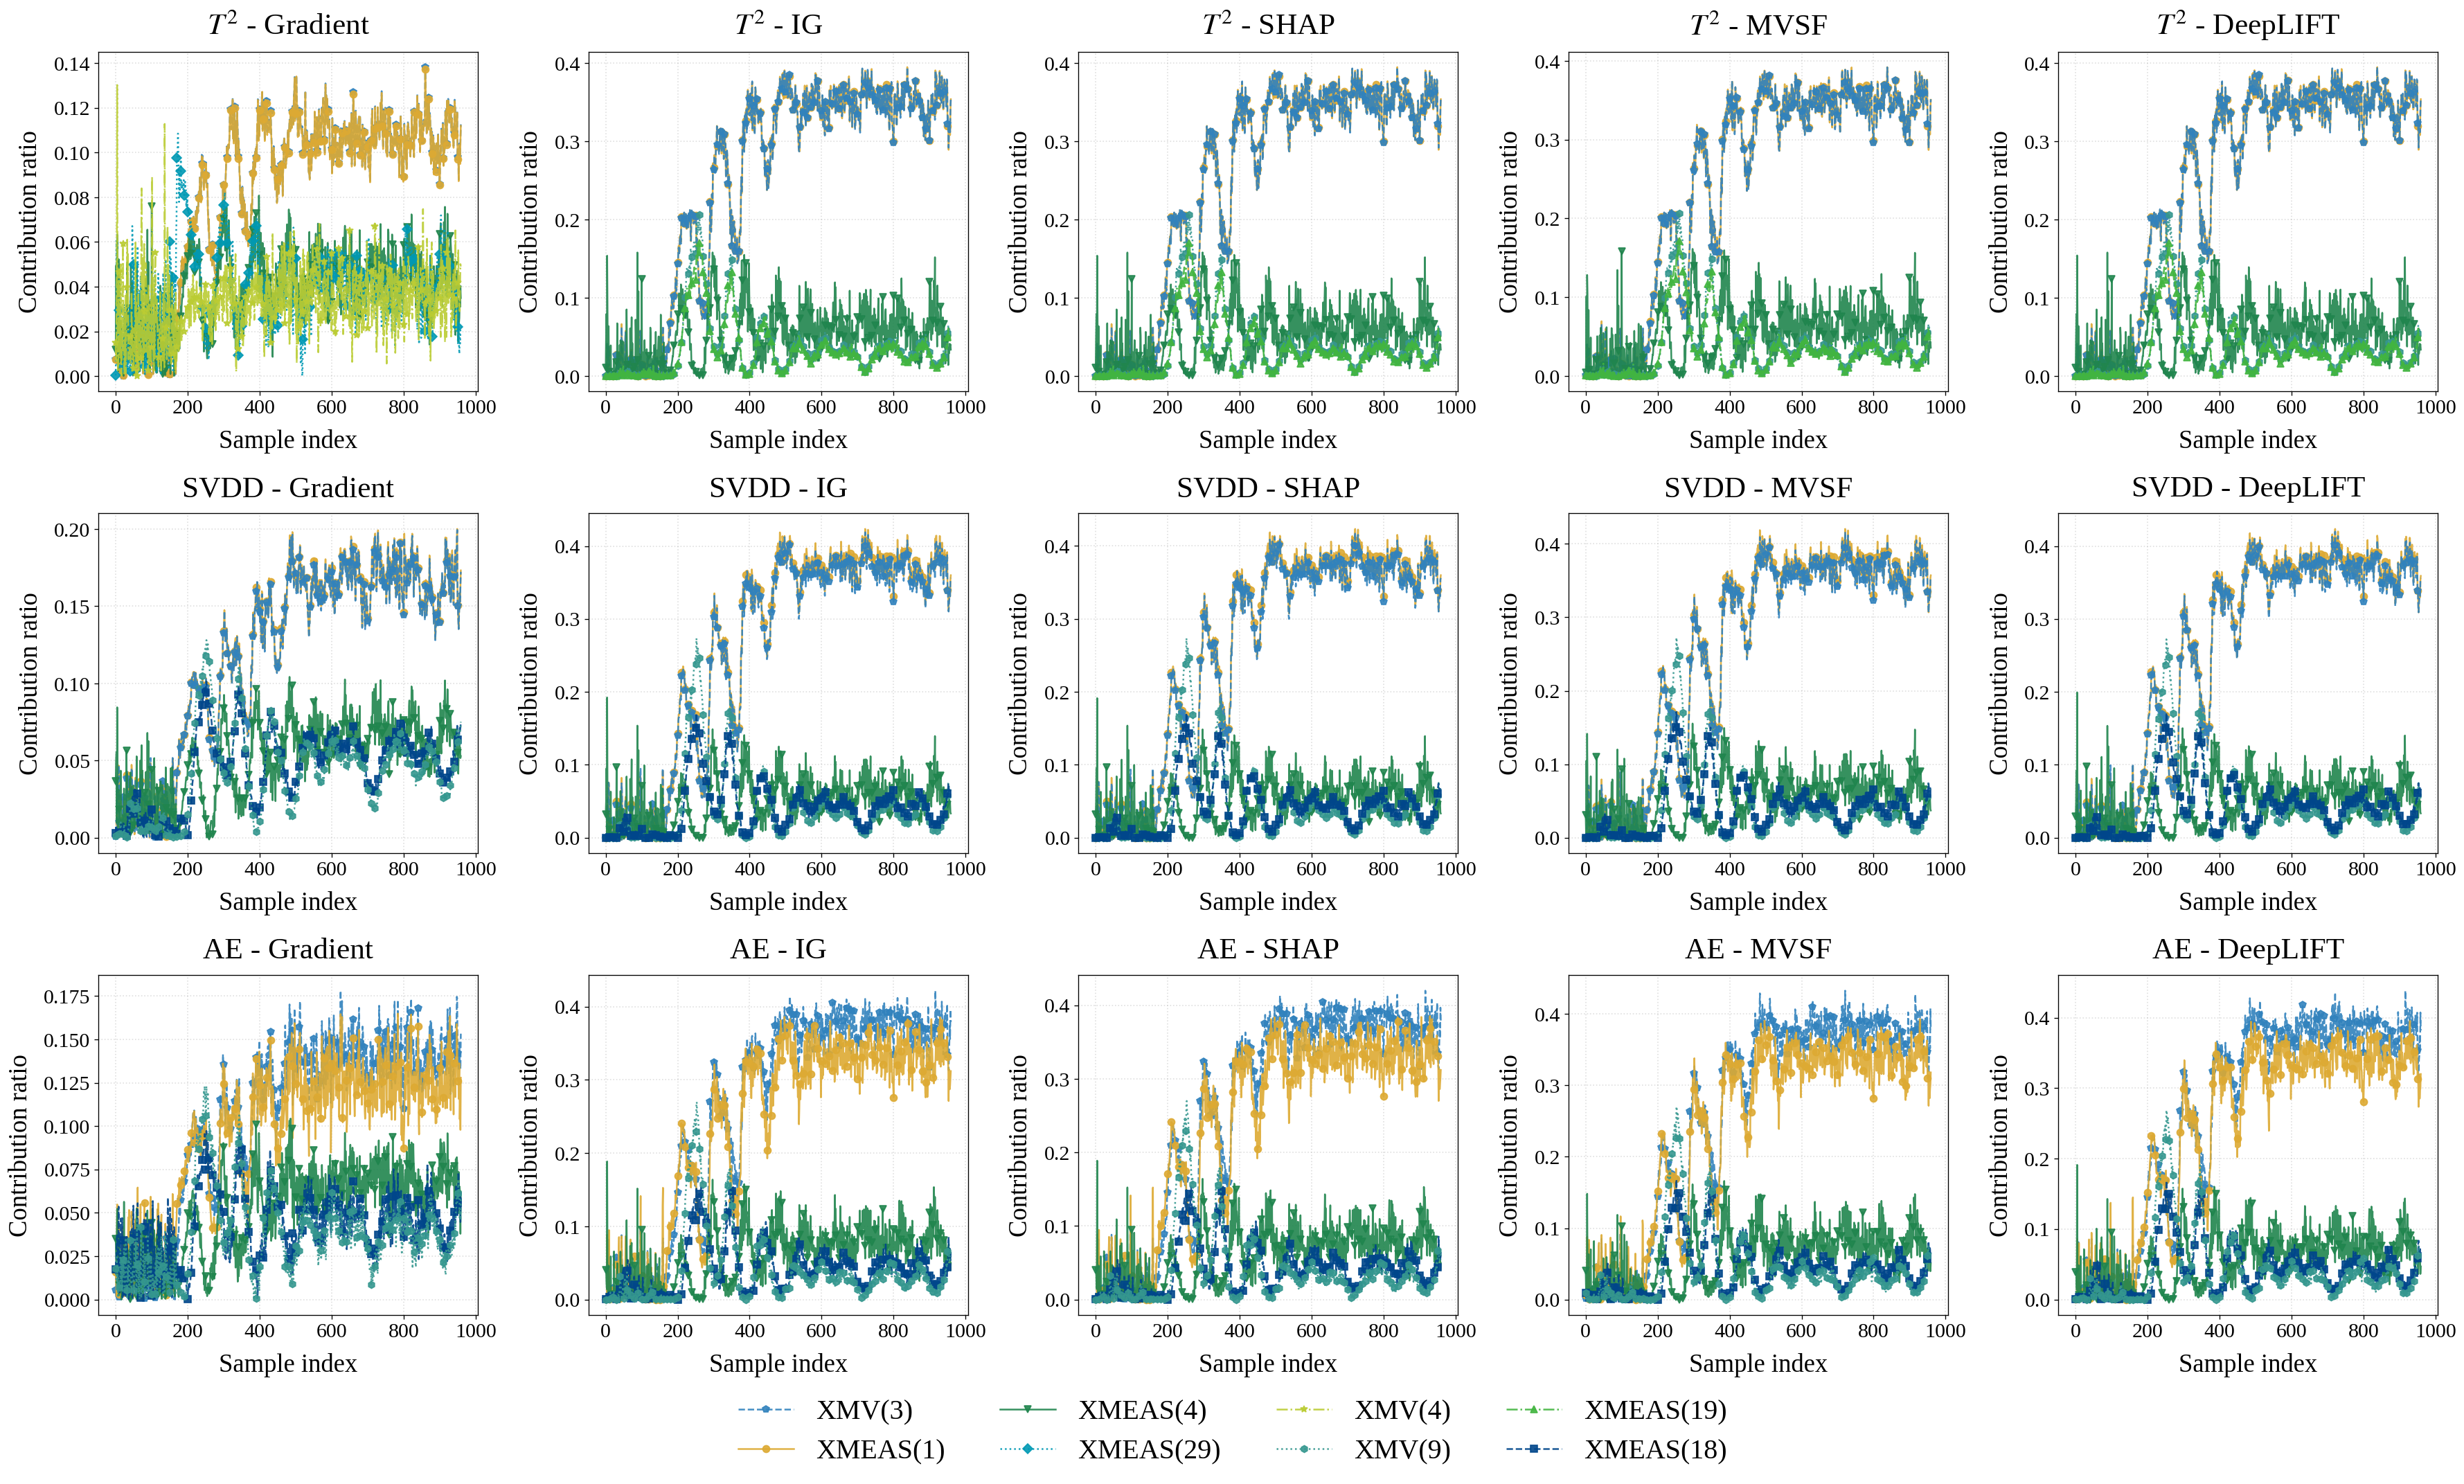

In [8]:
plot_known_fault_contribution_curves(
    contrib_dict_all=contrib_dict_all,
    feature_names=feature_names,
    top_k=5,
    save_dir="duoweiwei"
)

图形已保存至：removal_test_plot.pdf


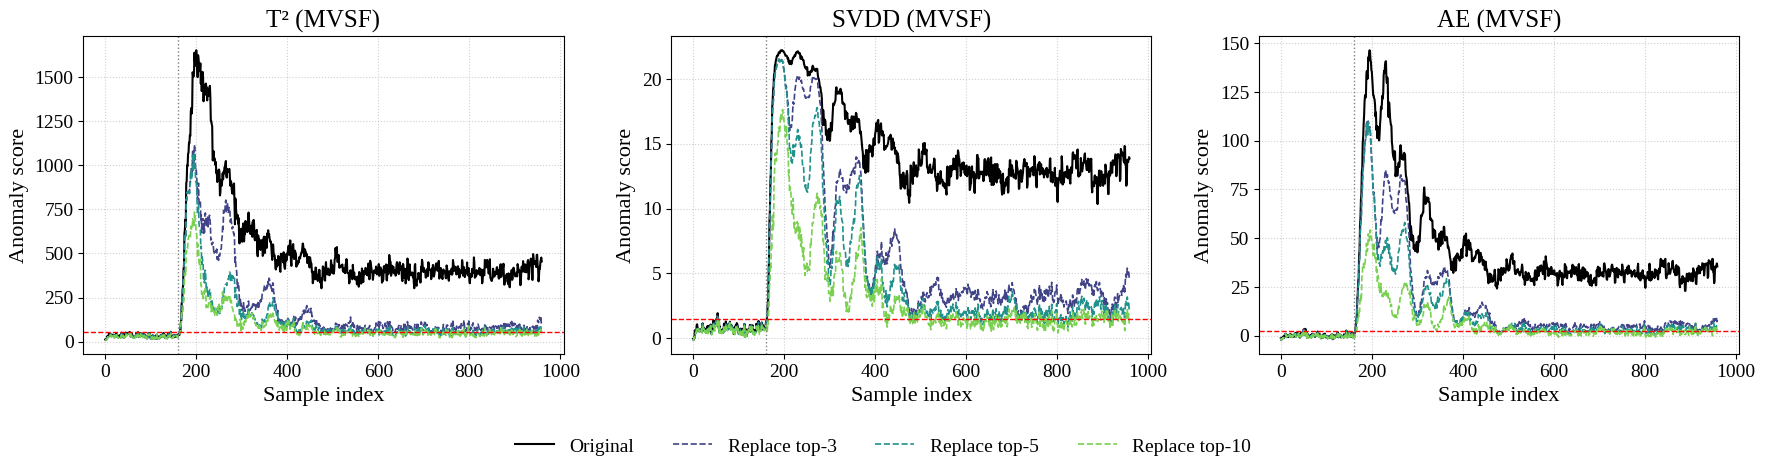

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt

def plot_removal_test_for_indicators(
    models, reference_points, x_test_scaled, threshold_dict,
    fault_start_idx=160, attribution_method="VSF",
    k_list=(3, 5, 10), figsize=(18, 5), save_path=None
):
    display_method = attribution_method.replace("VSF", "MVSF")
    
    indicator_names = list(models.keys())
    nrows = math.ceil(len(indicator_names) / 3)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(figsize[0], figsize[1] * nrows))
    axes_flat = axes.flatten() if nrows * 3 > 1 else [axes]

    for idx, model_name in enumerate(indicator_names):
        ax = axes_flat[idx]
        score_func = models[model_name]["score_numpy"]
        threshold = threshold_dict[model_name]
        reference = reference_points[model_name]

        # ==========================================
        # 严格对齐 6 个参数的 build_all_explainers
        # ==========================================
        explainer = build_all_explainers(
            model_name, 
            reference, 
            x_normal, 
            models, 
            [attribution_method]
        )[attribution_method]
        
        attrib_result = get_unified_output(explainer, x_test_scaled)

        # 使用归一化后的贡献
        contrib = attrib_result["raw_contrib"]
        order = np.argsort(-np.mean(contrib[fault_start_idx:], axis=0))

        ax.plot(score_func(x_test_scaled).ravel(), color="black", linewidth=1.5, label="Original")
        
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(k_list)))
        for i, k in enumerate(k_list):
            k = min(k, x_test_scaled.shape[1])
            x_removed = x_test_scaled.copy()
            x_removed[:, order[:k]] = reference[order[:k]]
            ax.plot(score_func(x_removed).ravel(), color=colors[i], linewidth=1.2, linestyle="--", label=f"Replace top-{k}")

        ax.axvline(fault_start_idx, color="gray", linestyle=":", linewidth=1)
        ax.axhline(threshold, color="red", linestyle="--", linewidth=1)
        
        ax.set_title(f"{model_name} ({display_method})", fontsize=18)
        ax.set_xlabel("Sample index", fontsize=16)
        ax.set_ylabel("Anomaly score", fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.grid(True, linestyle=":", alpha=0.6)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='lower center', 
               bbox_to_anchor=(0.5, 0.02), ncol=len(labels), 
               frameon=False, fontsize=14)

    for j in range(len(indicator_names), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.1, 1, 1])

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"图形已保存至：{save_path}")
    else:
        plt.show()

# =========================================
# 正确的调用方式
# =========================================
# 请确保此时内存中的 models, reference_points, x_outliers, thresholds 均已正确实例化
plot_removal_test_for_indicators(
    models=models,
    reference_points=reference_points,
    x_test_scaled=x_outliers,
    threshold_dict=thresholds,
    fault_start_idx=160,
    attribution_method="VSF",  
    save_path="removal_test_plot.pdf"
)

In [10]:
# 查看T²主元数量

pca = models["T²"]["meta"]["pca"]

print("T² 主元数量:", pca.n_components_)

print(
    "累计贡献率:",
    np.sum(pca.explained_variance_ratio_)
)

T² 主元数量: 31
累计贡献率: 0.90231854


In [11]:
import os
import pandas as pd
import numpy as np


def compute_fer_curve(score_func, x_test, threshold, contrib, ref):

    x_test = np.asarray(x_test, dtype=np.float32)
    contrib = np.asarray(contrib, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    
    n_features = x_test.shape[1]
    fer = []


    # ===============================
    # 1. 获取故障样本
    # ===============================

    original_scores = score_func(x_test).ravel()

    mask_fault = original_scores > threshold


    # 没检测到故障
    if np.sum(mask_fault) == 0:
        return np.zeros(n_features)



    # ===============================
    # 2. 计算变量贡献排序
    # ===============================

    contrib_fault = contrib[mask_fault]

    mean_abs = np.mean(
        np.abs(contrib_fault),
        axis=0
    )


    # 从大到小排序
    order = np.argsort(
        -mean_abs
    )



    # ===============================
    # 3. Top-k变量替换计算FER
    # ===============================

    for k in range(
        1,
        n_features + 1
    ):

        x_mod = x_test.copy()


        top_idx = order[:k]


        # xi_j(k)=xref_j
        x_mod[:, top_idx] = ref[top_idx]


        scores_fixed = score_func(
            x_mod
        ).ravel()


        # 故障消除
        eliminated = (
            (scores_fixed <= threshold)
            &
            mask_fault
        )


        fer_k = (
            np.sum(eliminated)
            /
            np.sum(mask_fault)
        )


        fer.append(
            fer_k
        )


    return np.array(fer)




def generate_global_fer_benchmark_table(
        DATA_PATH,
        models,
        thresholds,
        reference_points,
        scaler,
        method_labels
):


    print(
        "\n=============================="
        "\n开始计算21故障平均FER"
        "\n=============================="
    )



    global_records = []



    # ===============================
    # 三种监测模型
    # ===============================

    for model_name in [
        "T²"
    ]:


        print(
            f"\n处理中: {model_name}"
        )


        score_func = models[model_name]["score_numpy"]

        threshold = thresholds[model_name]

        ref = reference_points[model_name]



        explainers = build_all_explainers(
            model_name,
            ref,
            x_normal,
            models,
            method_labels
        )



        # ===============================
        # 21个TEP故障
        # ===============================

        for f_idx in range(
            1,
            22
        ):


            file_name = (
                f"d{f_idx:02d}_te.dat"
            )


            file_path = os.path.join(
                DATA_PATH,
                file_name
            )



            if not os.path.exists(
                file_path
            ):
                continue



            df_f = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None
            )



            x_test_f = scaler.transform(
                df_f.values
            ).astype(
                np.float32
            )



            # 去除正常阶段
            x_test_fault_only = x_test_f[160:]



            # ===============================
            # 不同解释方法
            # ===============================

            for method in method_labels:


                if (
                    method not in explainers
                    or
                    explainers[method] is None
                ):
                    continue



                try:


                    unified = get_unified_output(
                        explainers[method],
                        x_test_fault_only
                    )


                    contrib = unified[
                        "raw_contrib"
                    ]



                    fer_curve = compute_fer_curve(
                        score_func=score_func,
                        x_test=x_test_fault_only,
                        threshold=threshold,
                        contrib=contrib,
                        ref=ref
                    )



                    fer_3 = (
                        fer_curve[2]
                        if len(fer_curve)>=3
                        else 0.0
                    )


                    fer_5 = (
                        fer_curve[4]
                        if len(fer_curve)>=5
                        else 0.0
                    )


                    fer_10 = (
                        fer_curve[9]
                        if len(fer_curve)>=10
                        else 0.0
                    )



                    global_records.append(
                        {

                        "Model":
                        model_name,


                        "Fault":
                        f"F{f_idx}",


                        "Method":
                        method,


                        "Top-3":
                        fer_3*100,


                        "Top-5":
                        fer_5*100,


                        "Top-10":
                        fer_10*100

                        }
                    )



                except Exception as e:

                    print(
                        "Error:",
                        model_name,
                        f"F{f_idx}",
                        method,
                        e
                    )



    # ===============================
    # 所有故障结果
    # ===============================

    df = pd.DataFrame(
        global_records
    )



    # ===============================
    # 核心修改:
    # 21故障平均FER
    # ===============================


    mean_df = df.groupby(
        [
            "Model",
            "Method"
        ]
    )[
        [
            "Top-3",
            "Top-5",
            "Top-10"
        ]
    ].mean().reset_index()



    mean_df[
        [
            "Top-3",
            "Top-5",
            "Top-10"
        ]
    ] = mean_df[
        [
            "Top-3",
            "Top-5",
            "Top-10"
        ]
    ].round(2)




    # ===============================
    # 转换论文表格格式
    # ===============================


    paper_table = mean_df.pivot(
        index="Model",
        columns="Method",
        values=[
            "Top-3",
            "Top-5",
            "Top-10"
        ]
    )



    paper_table = paper_table.reorder_levels(
        [
            0,
            1
        ],
        axis=1
    ).sort_index(
        axis=1,
        level=0
    )



    # 保存

    paper_table.to_csv(
        "TEP_FER_mean_table.csv",
        encoding="utf_8_sig"
    )



    print(
        "\n成功生成21故障平均FER表"
    )



    return paper_table





# ===============================
# 执行
# ===============================


fer_mean_table = generate_global_fer_benchmark_table(
    DATA_PATH=DATA_PATH,
    models=models,
    thresholds=thresholds,
    reference_points=reference_points,
    scaler=scaler,
    method_labels=method_labels
)



# 查看论文表
fer_mean_table


开始计算21故障平均FER

处理中: T²

成功生成21故障平均FER表


Top-10                                  Top-3                         \
Method DeepLIFT Gradient     IG   SHAP    VSF DeepLIFT Gradient     IG   SHAP   
Model                                                                           
T²        62.22    59.13  62.22  62.22  62.88    43.85    39.74  43.85  43.85   

                 Top-5                               
Method    VSF DeepLIFT Gradient     IG   SHAP   VSF  
Model                                                
T²      43.93    52.29     48.1  52.29  52.29  52.8